In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    validation_curve
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

In [5]:
# Dataset Load
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df['Price'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

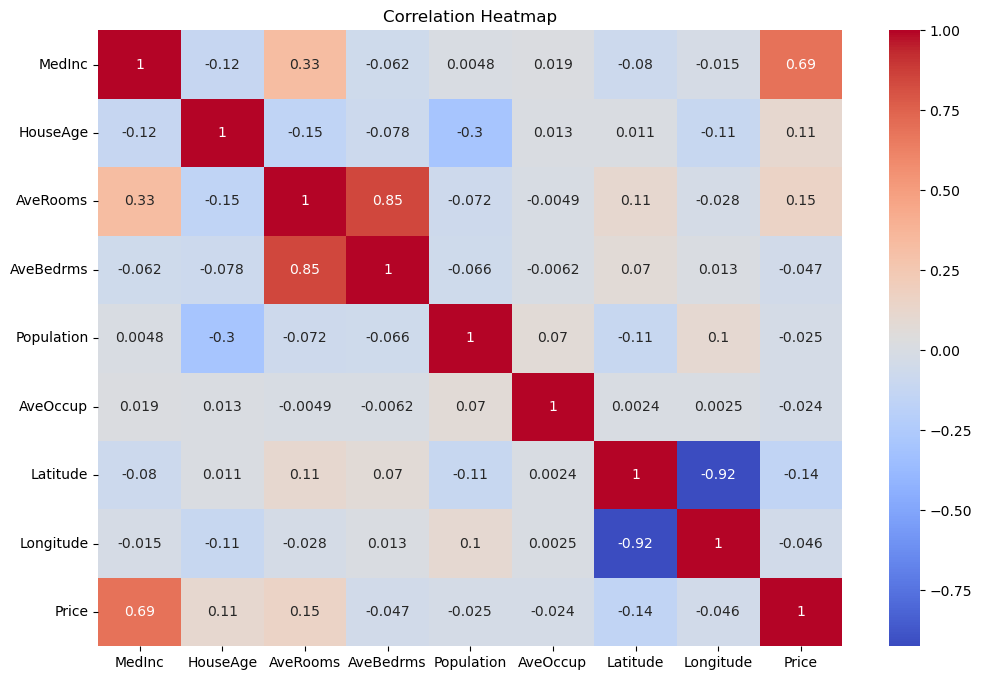

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [9]:
X = df.drop("Price", axis=1)

y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
baseline_model = DecisionTreeRegressor(
    random_state=42
)

baseline_model.fit(
    X_train,
    y_train
)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [11]:
train_pred = baseline_model.predict(X_train)

test_pred = baseline_model.predict(X_test)

train_r2 = r2_score(
    y_train,
    train_pred
)

test_r2 = r2_score(
    y_test,
    test_pred
)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

Train R²: 1.0
Test R² : 0.622075845135081


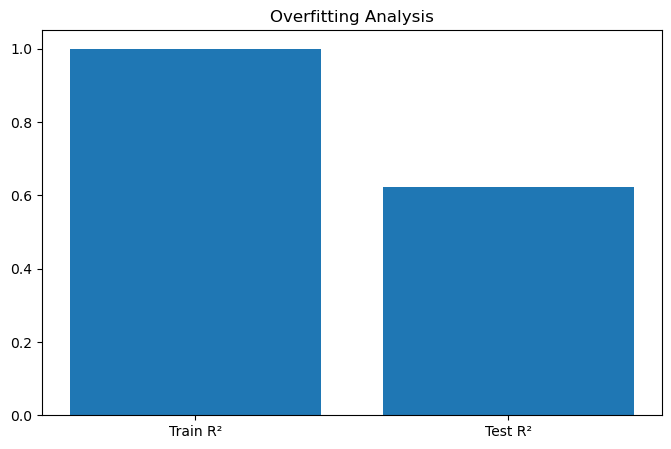

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Train R²","Test R²"],
    [train_r2,test_r2]
)

plt.title("Overfitting Analysis")

plt.show()

In [13]:
cv_scores = cross_val_score(
    baseline_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(cv_scores)

print("Average CV Score:",
      cv_scores.mean())

[0.27093461 0.41372445 0.43912441 0.23566991 0.41875969]
Average CV Score: 0.355642615410327


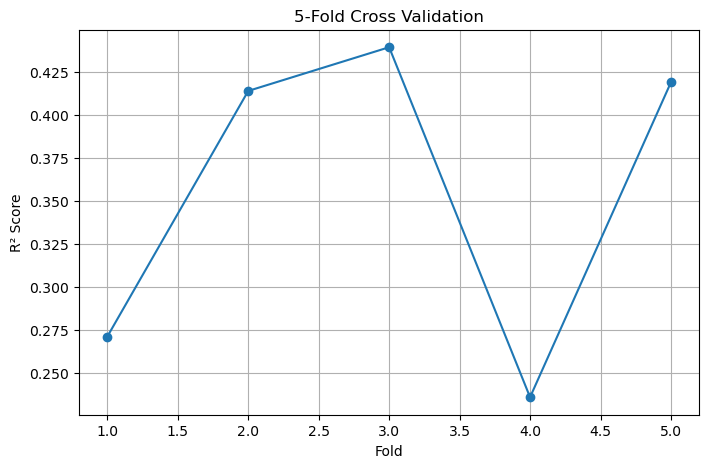

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,6),
    cv_scores,
    marker='o'
)

plt.xlabel("Fold")

plt.ylabel("R² Score")

plt.title("5-Fold Cross Validation")

plt.grid()

plt.show()

In [16]:
param_grid = {
    "max_depth":[
        3,5,7,10,None
    ],

    "min_samples_split":[
        2,5,10
    ],

    "min_samples_leaf":[
        1,2,4
    ]
}

In [18]:
grid = GridSearchCV(
    estimator=DecisionTreeRegressor(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [19]:
print("Best Parameters:")

print(grid.best_params_)

print()

print("Best CV Score:")

print(grid.best_score_)


Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best CV Score:
0.7100830403599112


In [21]:
best_model = grid.best_estimator_

best_model.fit(
    X_train,
    y_train
)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [23]:
pred = best_model.predict(
    X_test
)

In [24]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

r2 = r2_score(
    y_test,
    pred
)

print("RMSE:", rmse)

print("R² Score:", r2)

RMSE: 0.6390654005312799
R² Score: 0.6883380738855668


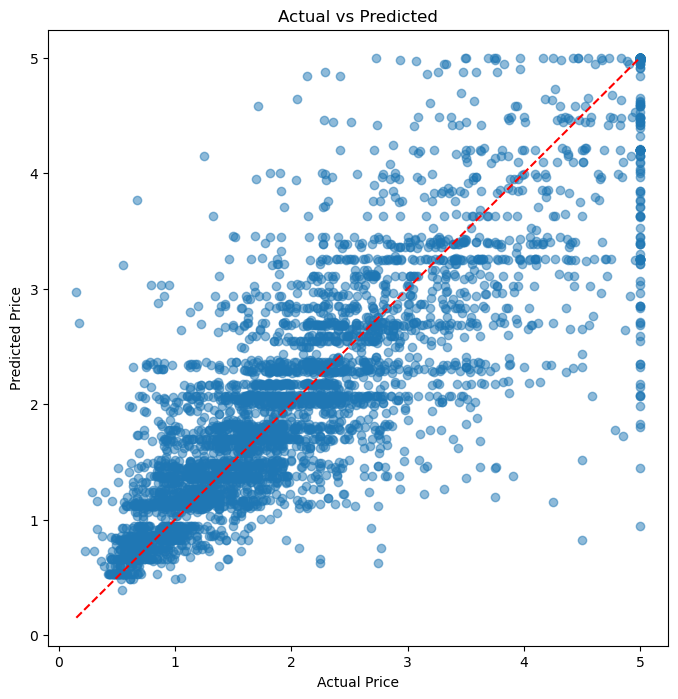

In [26]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

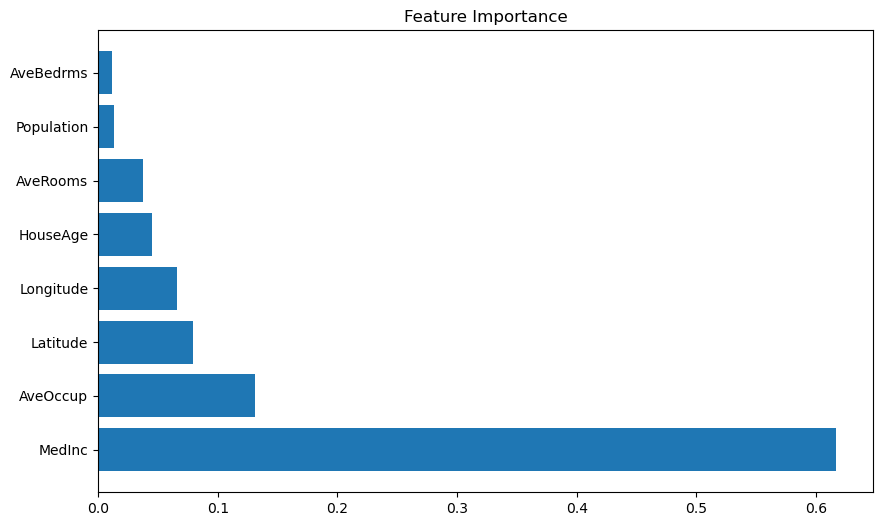

In [27]:
importance = best_model.feature_importances_

feat = pd.DataFrame({
    "Feature":X.columns,
    "Importance":importance
})

feat = feat.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feat["Feature"],
    feat["Importance"]
)

plt.title("Feature Importance")

plt.show()

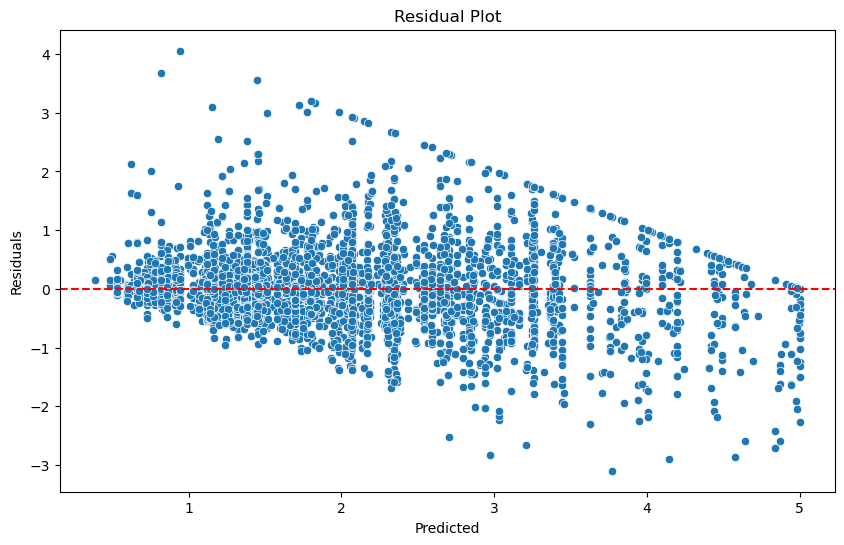

In [28]:
residuals = y_test - pred

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.show()

In [30]:
train_scores, test_scores = validation_curve(
    DecisionTreeRegressor(
        random_state=42
    ),

    X,
    y,

    param_name="max_depth",

    param_range=[
        1,2,3,4,5,7,10,15,20
    ],

    cv=5,

    scoring="r2"
)

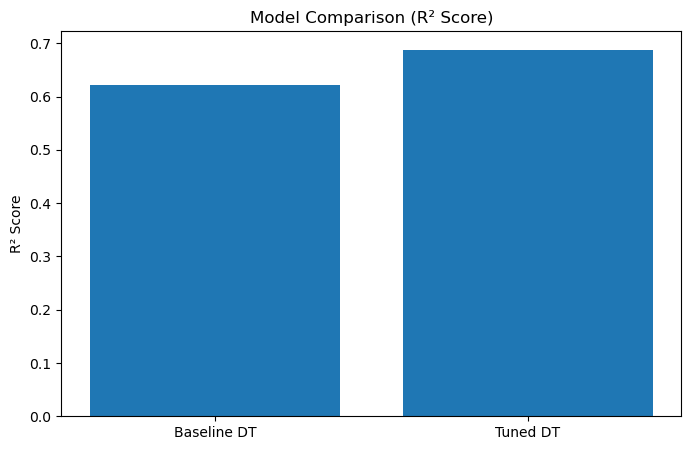

In [31]:
models = ['Baseline DT', 'Tuned DT']
r2_scores = [test_r2, r2]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")

plt.show()

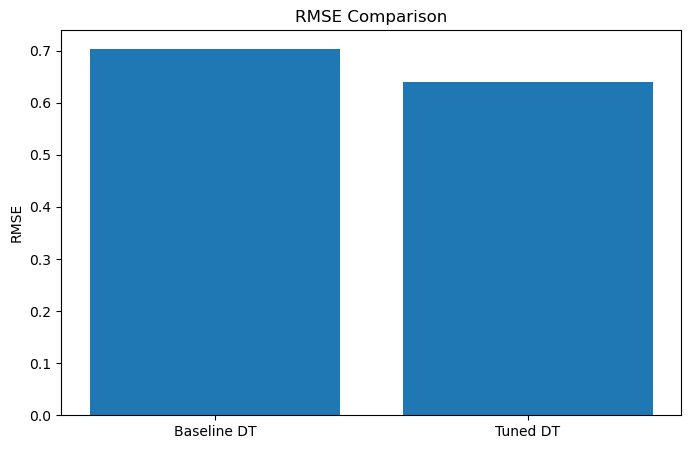

In [32]:
baseline_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

rmse_values = [baseline_rmse, rmse]

plt.figure(figsize=(8,5))
plt.bar(
    ['Baseline DT', 'Tuned DT'],
    rmse_values
)

plt.title("RMSE Comparison")
plt.ylabel("RMSE")

plt.show()

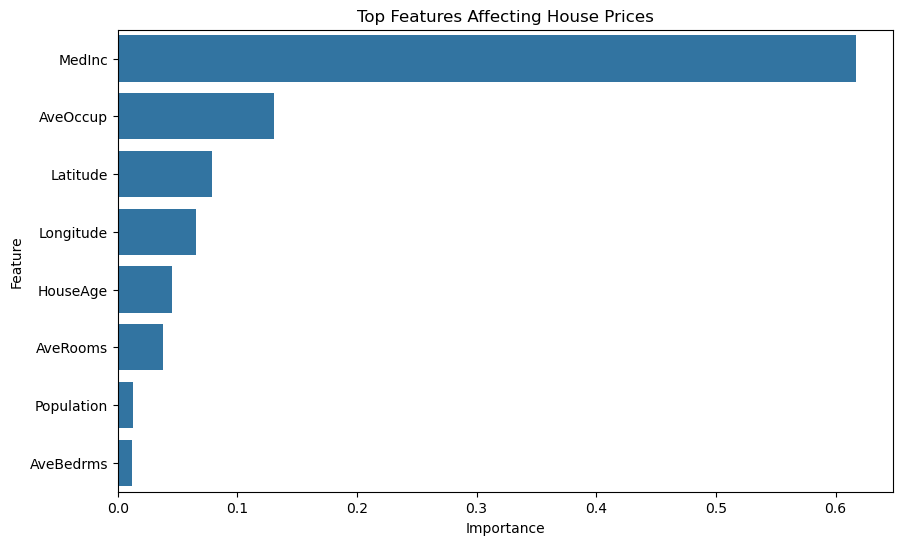

In [33]:
feat = feat.head(8)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feat
)

plt.title("Top Features Affecting House Prices")

plt.show()

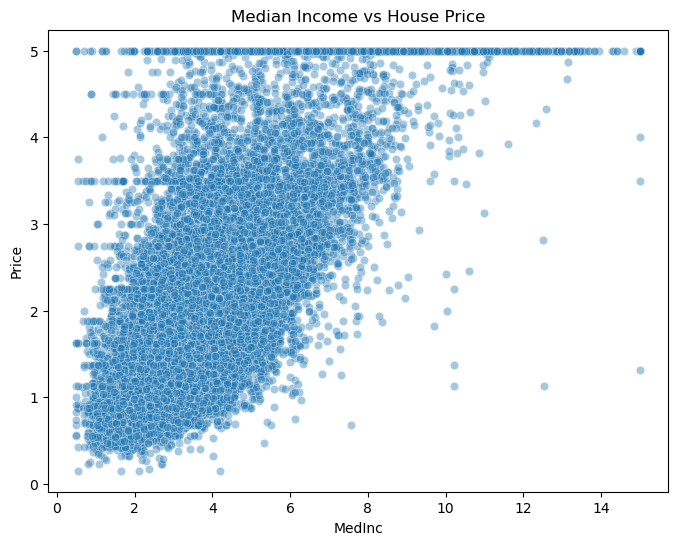

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['MedInc'],
    y=df['Price'],
    alpha=0.4
)

plt.title("Median Income vs House Price")

plt.show()